In [107]:
from pathlib import Path
from typing import Optional, Tuple
import tifffile
from liffile import LifFile
import numpy as np
import napari
import os
from magicgui import magicgui
from magicgui.widgets import Container, TextEdit
from skimage import util
from skimage.filters import threshold_triangle, median, sobel, gaussian, threshold_yen, threshold_otsu
from skimage.measure import label, regionprops_table, regionprops, moments_central
from skimage.morphology import disk, remove_small_objects, remove_small_holes, closing, opening, binary_opening, binary_closing, erosion
from skimage.transform import ProjectiveTransform, warp, probabilistic_hough_line
from scipy.ndimage import rotate, binary_dilation, binary_fill_holes
from skimage.draw import line
from skimage.io import imread
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from skimage import exposure
from skimage.filters import threshold_multiotsu
from skimage.segmentation import expand_labels




In [39]:
image_folder = Path(r"Z:\\Bel\\Marina_Area_PDO\\260310")
png_paths = sorted(image_folder.glob("*.png"))

In [137]:
test = gaussian(util.invert(imread(png_paths[6])),sigma=1)

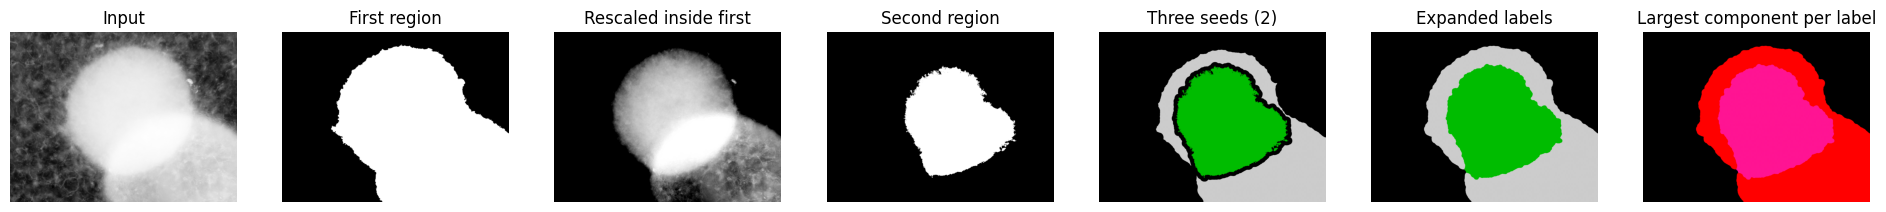

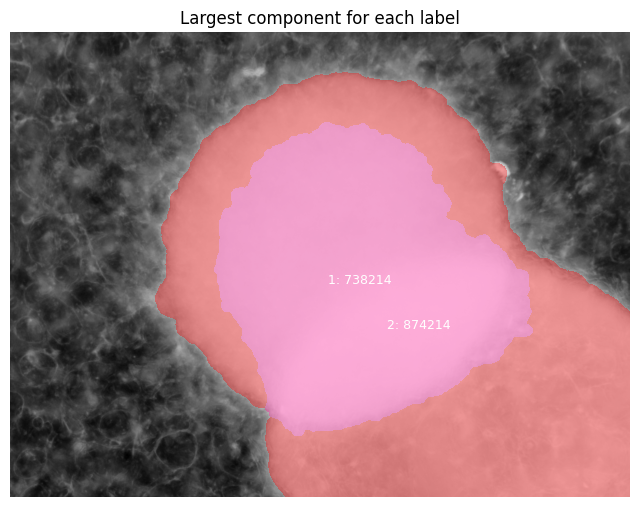

First region area: 1622199 px
Label 1 (second_region) area: 738214 px
Label 2 (hole_and_shadow_part_1) area: 874214 px


In [160]:
def largest_component(mask):
    labels = label(mask)
    if labels.max() == 0:
        return np.zeros_like(mask, dtype=bool)
    areas = np.bincount(labels.ravel())
    areas[0] = 0
    return labels == areas.argmax()


hole_and_shadow = largest_component(remove_small_holes(test > threshold_otsu(test), max_size=16000))
masked_rescaled = np.zeros_like(test, dtype=float)
if hole_and_shadow.any():
    low, high = np.percentile(test[hole_and_shadow], (5, 90))
    masked_rescaled[hole_and_shadow] = exposure.rescale_intensity(test[hole_and_shadow], in_range=(low, high), out_range=(0, 1))


hole_and_shadow_classes = np.zeros_like(hole_and_shadow, dtype=int)
if hole_and_shadow.any() and np.unique(masked_rescaled[hole_and_shadow]).size > 1:
    hole_and_shadow_classes[hole_and_shadow] = np.digitize(
        masked_rescaled[hole_and_shadow],
        bins=threshold_multiotsu(masked_rescaled[hole_and_shadow], classes=3),
    )

    
second_region = largest_component(hole_and_shadow & (hole_and_shadow_classes == hole_and_shadow_classes[hole_and_shadow].max())) if hole_and_shadow.any() else np.zeros_like(hole_and_shadow, dtype=bool)
remainder_region = remove_small_objects(hole_and_shadow & ~second_region, max_size=499)
raw_seed_labels = label(erosion(remainder_region, disk(35)))
seed_labels = np.where(second_region, 1, 0)
seed_areas = np.bincount(raw_seed_labels.ravel()) if raw_seed_labels.max() else np.array([0])
if raw_seed_labels.max():
    seed_areas[0] = 0
    for new_label, old_label in enumerate(np.argsort(seed_areas)[-2:][::-1], start=2):
        if seed_areas[old_label] > 0:
            seed_labels[raw_seed_labels == old_label] = new_label

expanded_all_labels = expand_labels(seed_labels, distance=35) * hole_and_shadow.astype(int)
combined_labels = np.zeros_like(hole_and_shadow, dtype=int)
region_summaries = []

for source_label, final_label, name in ((1, 1, "second_region"), (2, 2, "hole_and_shadow_part_1"), (3, 3, "hole_and_shadow_part_2")):
    component = largest_component(expanded_all_labels == source_label)
    if not component.any():
        continue
    combined_labels[component] = final_label
    y_coord, x_coord = np.argwhere(component).mean(axis=0)
    region_summaries.append((final_label, name, int(component.sum()), (y_coord, x_coord)))

combined_cmap = ListedColormap(["black", "darkorange", "dodgerblue", "deeppink", "limegreen", "red"] )

fig, ax = plt.subplots(ncols=7, figsize=(24, 4))
ax[0].imshow(test, cmap="gray")
ax[0].set_title("Input")
ax[1].imshow(hole_and_shadow, cmap="gray")
ax[1].set_title("First region")
ax[2].imshow(masked_rescaled, cmap="gray")
ax[2].set_title("Rescaled inside first")
ax[3].imshow(second_region, cmap="gray")
ax[3].set_title("Second region")
ax[4].imshow(seed_labels, cmap="nipy_spectral")
ax[4].set_title(f"Three seeds ({int(seed_labels.max())})")
ax[5].imshow(expanded_all_labels, cmap="nipy_spectral")
ax[5].set_title("Expanded labels")
ax[6].imshow(combined_labels, cmap=combined_cmap, vmin=0, vmax=max(1, combined_labels.max()))
ax[6].set_title("Largest component per label")
for axis in ax:
    axis.axis("off")
plt.show()

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(test, cmap="gray")
ax.imshow(
    combined_labels,
    cmap=combined_cmap,
    vmin=0,
    vmax=max(1, combined_labels.max()),
    alpha=np.where(combined_labels > 0, 0.35, 0.0),
    interpolation="none",
)
for label_value, region_name, area, (y_coord, x_coord) in region_summaries:
    ax.text(x_coord, y_coord, f"{label_value}: {area}", color="white", ha="center", va="center", fontsize=9)
ax.set_title("Largest component for each label")
ax.axis("off")
plt.show()

print(f"First region area: {int(hole_and_shadow.sum())} px")
for label_value, region_name, area, centroid in region_summaries:
    print(f"Label {label_value} ({region_name}) area: {area} px")

(np.float64(-0.5), np.float64(2047.5), np.float64(1535.5), np.float64(-0.5))

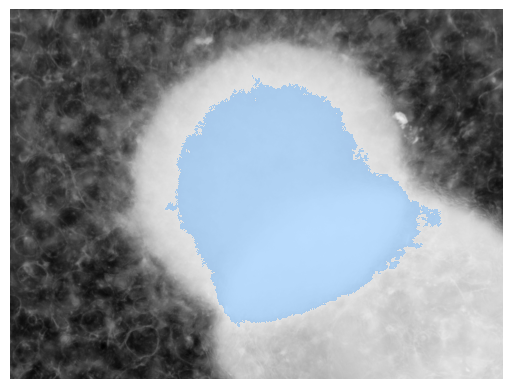

In [145]:
plt.imshow(test, cmap="gray")
plt.imshow(
    second_region.astype(int),
    cmap=ListedColormap(["black", "dodgerblue"]),
    alpha=np.where(second_region, 0.3, 0.0),
    interpolation="none",
)
plt.axis("off")

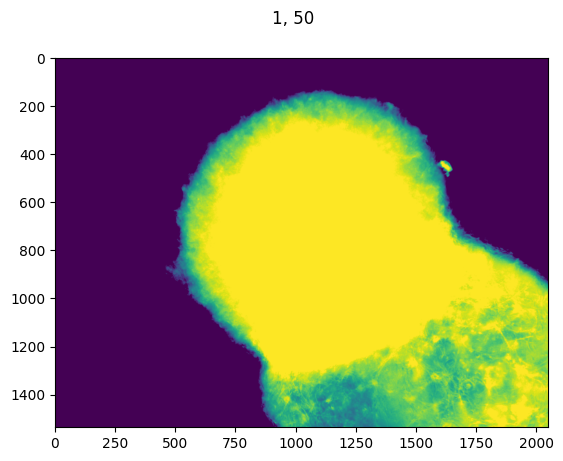

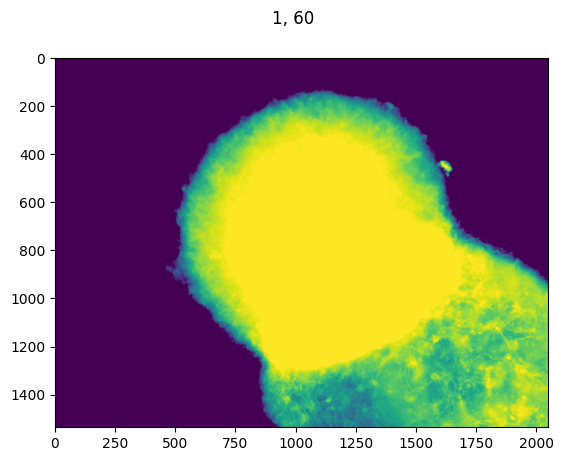

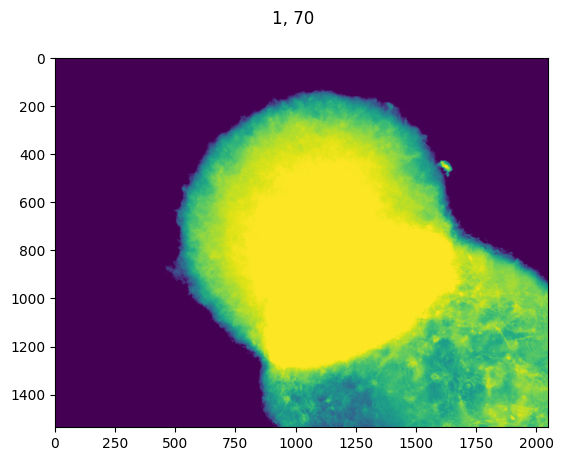

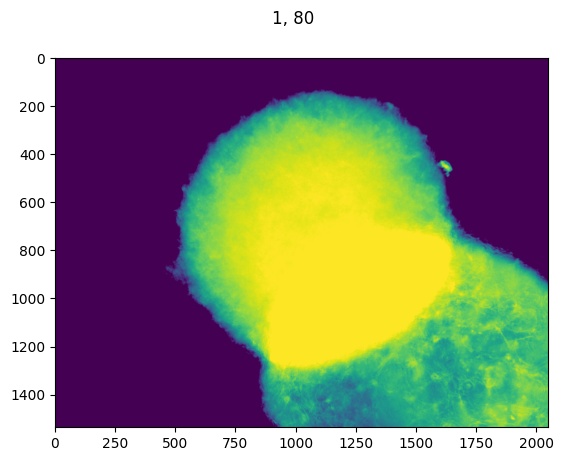

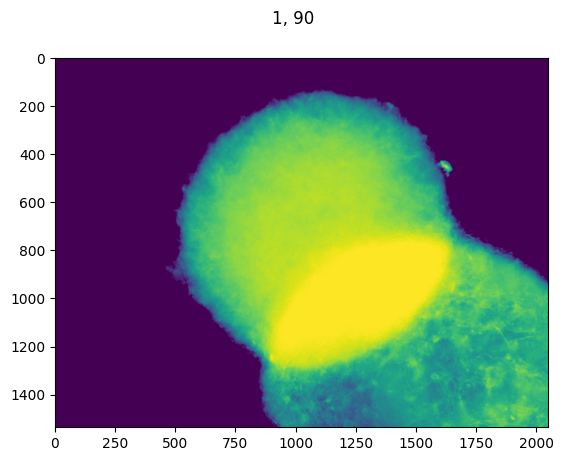

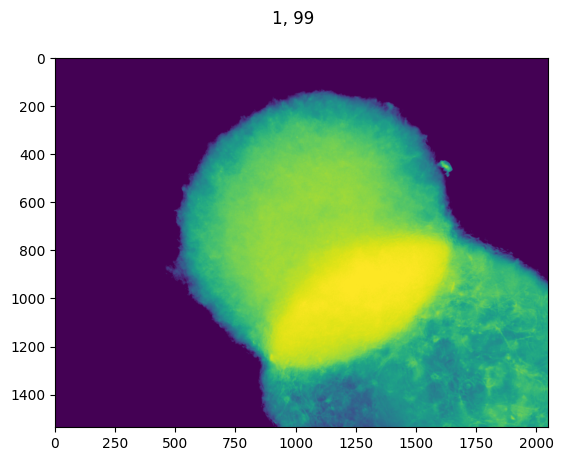

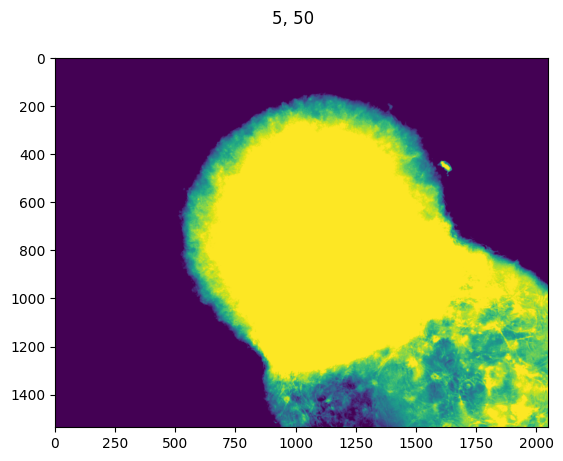

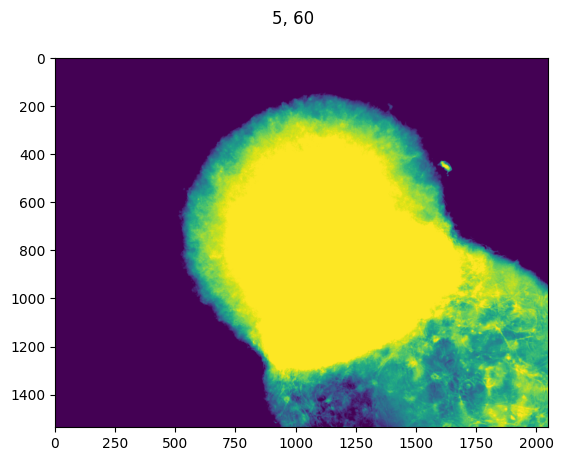

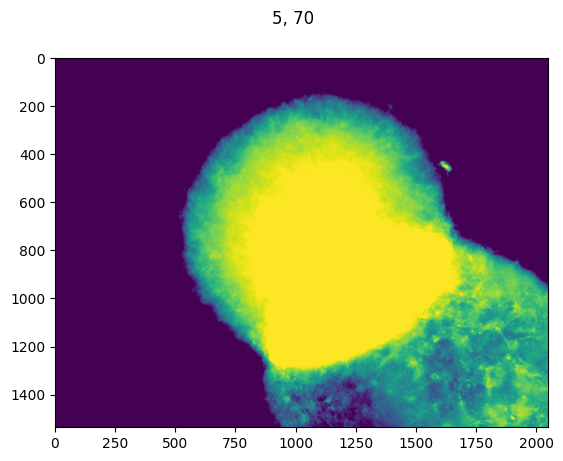

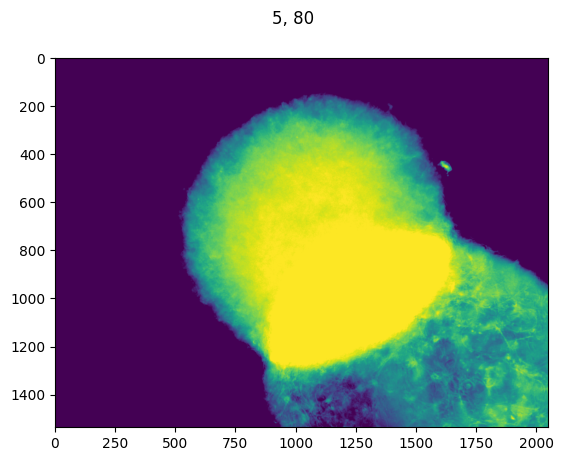

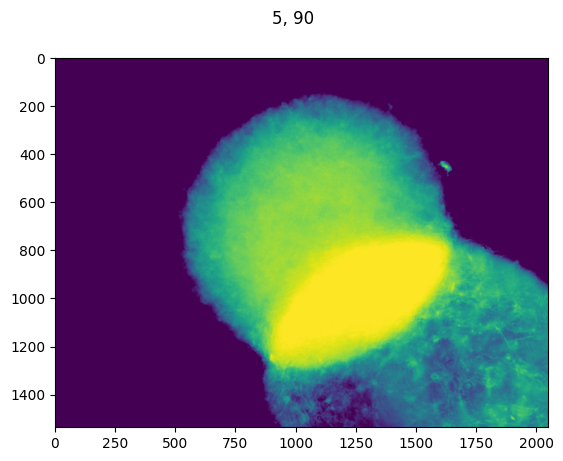

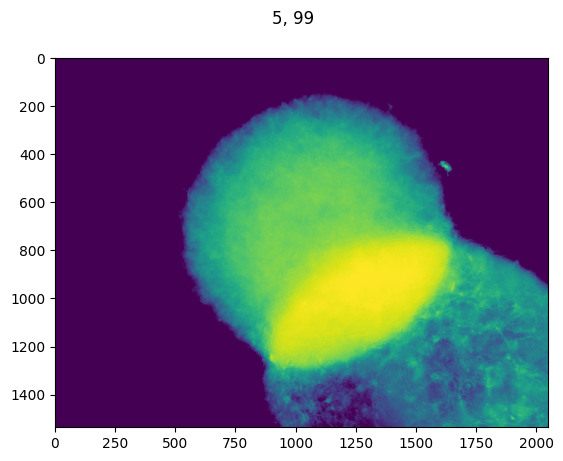

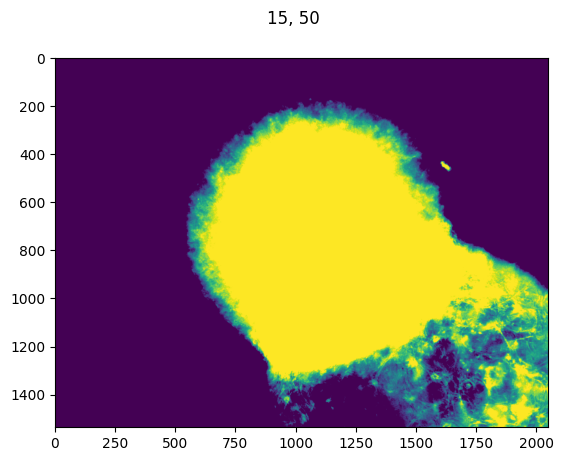

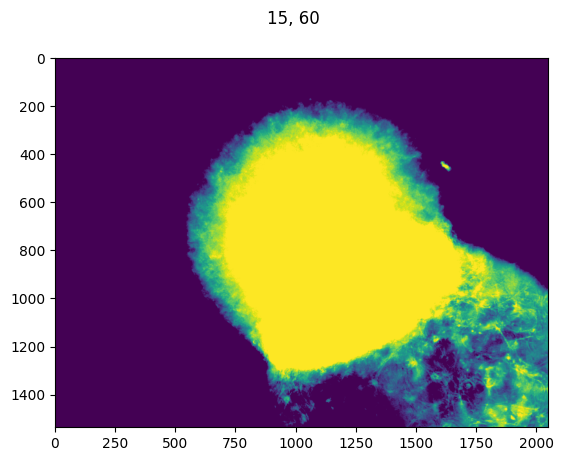

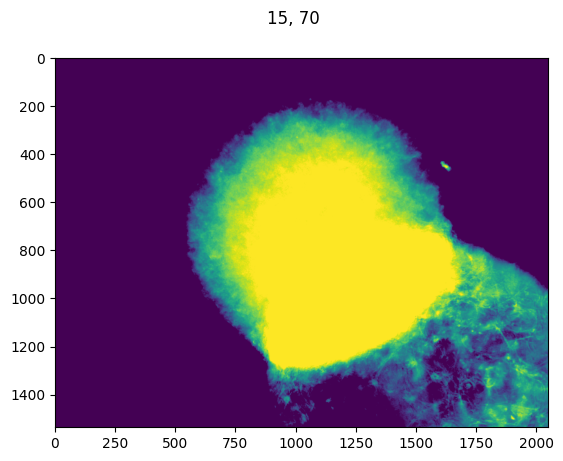

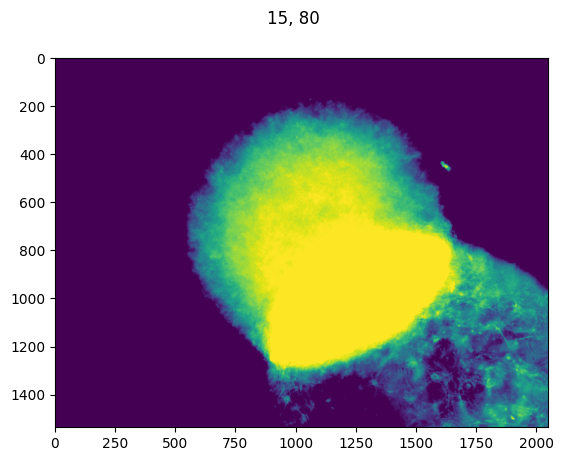

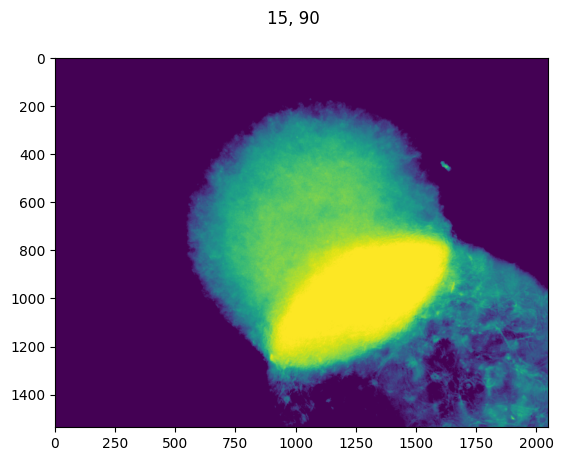

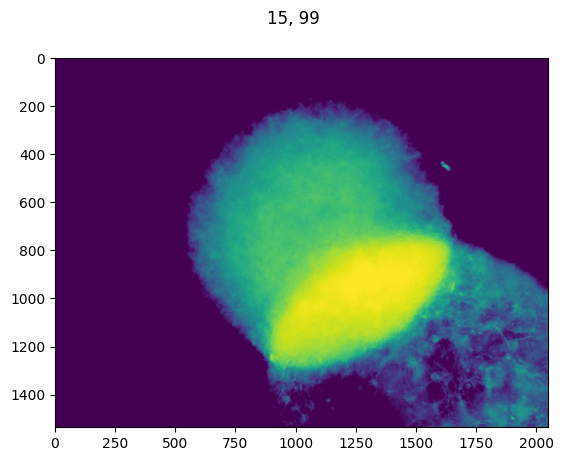

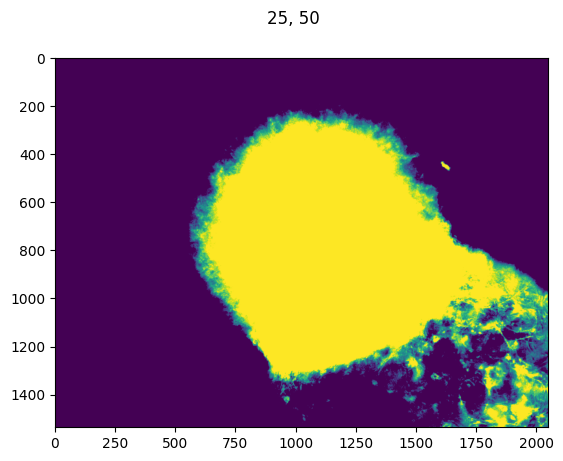

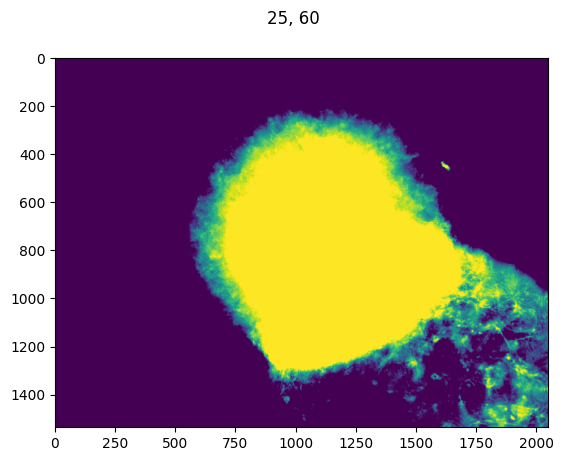

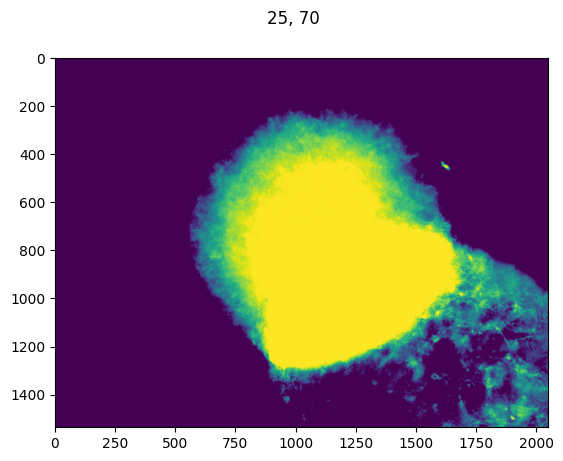

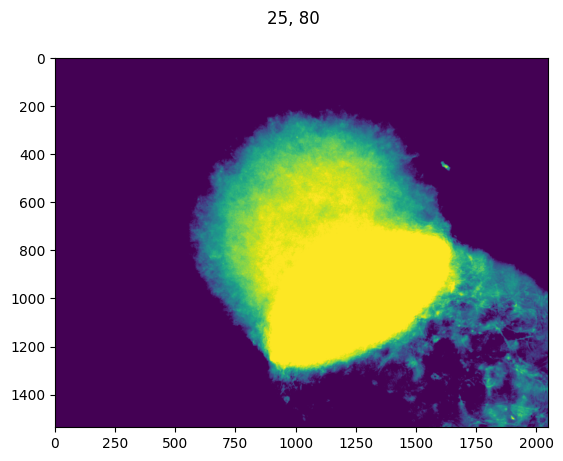

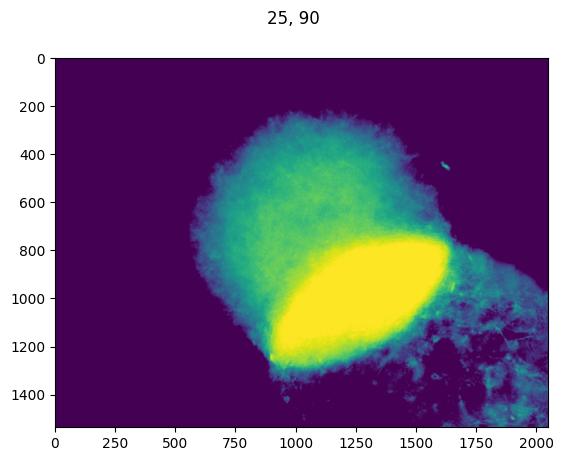

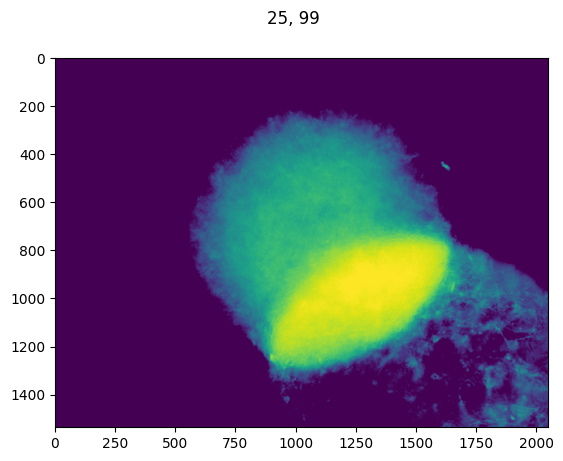

In [149]:

for low_i in [1,5,15,25]:
    for high_i in [50,60,70,80,90,99]:

        masked_rescaled = np.zeros_like(test, dtype=float)
        low, high = np.percentile(test[hole_and_shadow], (low_i, high_i))
        masked_rescaled[hole_and_shadow] = exposure.rescale_intensity(test[hole_and_shadow], in_range=(low, high), out_range=(0, 1))

        plt.imshow(masked_rescaled)
        plt.suptitle(f"{low_i}, {high_i}")
        plt.show()
# hole_and_shadow_classes = np.zeros_like(hole_and_shadow, dtype=int)
# if hole_and_shadow.any() and np.unique(masked_rescaled[hole_and_shadow]).size > 1:
#     hole_and_shadow_classes[hole_and_shadow] = np.digitize(
#         masked_rescaled[hole_and_shadow],
#         bins=threshold_multiotsu(masked_rescaled[hole_and_shadow], classes=3),
#     )
    

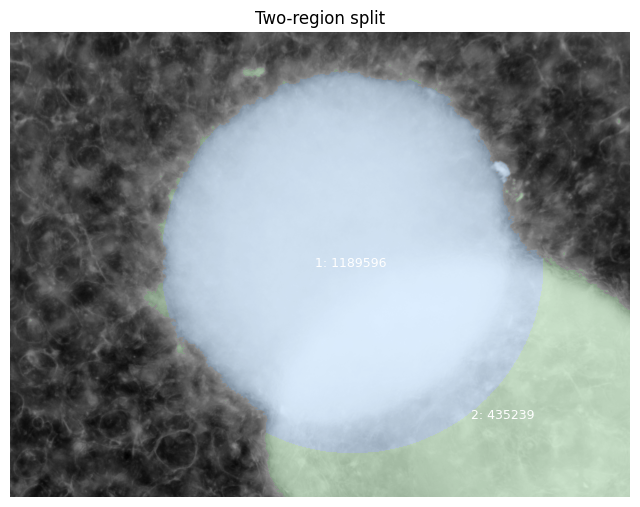

First region area: 1624835 px
Object centroid (x, y): (1259.7, 897.8)
Expected radius from first-region edge: 725.0 px
Detected circle center/radius: (1131.0, 760.0) / 631.0 px
Label 1 (target_circle) area: 1189596 px
Label 2 (remainder) area: 435239 px


In [178]:
def largest_component(mask):
    labels = label(mask)
    if labels.max() == 0:
        return np.zeros_like(mask, dtype=bool)
    areas = np.bincount(labels.ravel())
    areas[0] = 0
    return labels == areas.argmax()

from skimage.transform import hough_circle, hough_circle_peaks

test = gaussian(util.invert(imread(png_paths[6])), sigma=1)
# hole_and_shadow = largest_component(remove_small_holes(test > threshold_otsu(test), max_size=16000))
hole_and_shadow = test> threshold_otsu(test)
masked_rescaled = np.zeros_like(test, dtype=float)
if hole_and_shadow.any():
    low, high = np.percentile(test[hole_and_shadow], (5, 90))
    masked_rescaled[hole_and_shadow] = exposure.rescale_intensity(
        test[hole_and_shadow],
        in_range=(low, high),
        out_range=(0, 1),
    )

h, w = test.shape
yy, xx = np.indices(test.shape)
object_center = np.array(np.argwhere(hole_and_shadow).mean(axis=0)) if hole_and_shadow.any() else np.array([h / 2, w / 2])
hole_shadow_edge = hole_and_shadow & ~erosion(hole_and_shadow, disk(1))
edge_coords = np.argwhere(hole_shadow_edge)

second_region = np.zeros_like(hole_and_shadow, dtype=bool)
circle_params = None

if edge_coords.size:
    edge_distances = np.sqrt((edge_coords[:, 0] - object_center[0]) ** 2 + (edge_coords[:, 1] - object_center[1]) ** 2)
    expected_radius = float(np.percentile(edge_distances, 55))
    radius_min = max(20, int(expected_radius * 0.65))
    radius_max = min(min(h, w) // 2, int(expected_radius * 1.10))
    radius_range = np.arange(radius_min, max(radius_min + 2, radius_max), 4)

    if radius_range.size:
        hough_res = hough_circle(hole_shadow_edge.astype(np.uint8), radius_range)
        accums, cx, cy, radii = hough_circle_peaks(
            hough_res,
            radius_range,
            total_num_peaks=15,
        )

        best_score = -np.inf
        for accum, x_coord, y_coord, radius in zip(accums, cx, cy, radii):
            center = np.array([y_coord, x_coord], dtype=float)
            center_distance = np.linalg.norm(center - object_center) / max(h, w)
            radius_penalty = abs(radius - expected_radius) / max(expected_radius, 1.0)
            lower_bias = max(0.0, (y_coord - object_center[0]) / h)
            touches_edge = (
                y_coord - radius <= 0
                or y_coord + radius >= h - 1
                or x_coord - radius <= 0
                or x_coord + radius >= w - 1
            )
            if touches_edge:
                continue
            score = accum - 1.8 * center_distance - 1.2 * radius_penalty - 1.5 * lower_bias
            if score > best_score:
                best_score = score
                circle_params = (float(y_coord), float(x_coord), float(radius))

if circle_params is not None:
    y_coord, x_coord, radius = circle_params
    second_region = ((yy - y_coord) ** 2 + (xx - x_coord) ** 2 <= radius ** 2) & hole_and_shadow
    second_region = largest_component(second_region)

remainder_region = hole_and_shadow & ~second_region
combined_labels = np.zeros_like(hole_and_shadow, dtype=int)
if second_region.any():
    combined_labels[second_region] = 1
if remainder_region.any():
    combined_labels[remainder_region] = 2

region_summaries = []
for label_value, region_name in ((1, "target_circle"), (2, "remainder")):
    component = combined_labels == label_value
    if not component.any():
        continue
    y_coord, x_coord = np.argwhere(component).mean(axis=0)
    region_summaries.append((label_value, region_name, int(component.sum()), (y_coord, x_coord)))

combined_cmap = ListedColormap(["black", "dodgerblue", "limegreen"] )

# fig, ax = plt.subplots(ncols=6, figsize=(22, 4))
# ax[0].imshow(test, cmap="gray")
# ax[0].set_title("Input")
# ax[1].imshow(hole_and_shadow, cmap="gray")
# ax[1].set_title("First region")
# ax[2].imshow(masked_rescaled, cmap="gray")
# ax[2].set_title("Rescaled inside first")
# ax[3].imshow(hole_shadow_edge, cmap="gray")
# ax[3].set_title("First-region edge")
# ax[4].imshow(second_region, cmap="gray")
# ax[4].set_title("Detected circle")
# ax[5].imshow(combined_labels, cmap=combined_cmap, vmin=0, vmax=2)
# ax[5].set_title("Two regions")
# for axis in ax:
#     axis.axis("off")
# plt.show()


fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(test, cmap="gray")
ax.imshow(
    combined_labels,
    cmap=combined_cmap,
    vmin=0,
    vmax=2,
    alpha=np.where(combined_labels > 0, 0.15, 0.0),
    interpolation="none",
)
for label_value, region_name, area, (y_coord, x_coord) in region_summaries:
    ax.text(x_coord, y_coord, f"{label_value}: {area}", color="white", ha="center", va="center", fontsize=9)
ax.set_title("Two-region split")
ax.axis("off")
plt.show()

print(f"First region area: {int(hole_and_shadow.sum())} px")
print(f"Object centroid (x, y): ({object_center[1]:.1f}, {object_center[0]:.1f})")
print(f"Expected radius from first-region edge: {expected_radius:.1f} px")
if circle_params is not None:
    print(f"Detected circle center/radius: ({circle_params[1]:.1f}, {circle_params[0]:.1f}) / {circle_params[2]:.1f} px")
for label_value, region_name, area, centroid in region_summaries:
    print(f"Label {label_value} ({region_name}) area: {area} px")
